# IBKR API notebook

#### Connection

In [ ]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from ib_async import *
import pandas as pd
util.startLoop()
global historical_data_interval, duration

ib = IB()
ib.connect('127.0.0.1', 7497, clientId=14)
if ib.isConnected():
    print("✅ Connected to IBKR API")
else:
    print("❌Failed to connect to IBKR API")
util.logToConsole(logging.INFO)

## Request Historical data

#### Choose your contract

In [ ]:
#contract = CFD('IBUST100', 'SMART', 'USD')
#contract = Forex(pair="EURUSD", exchange='IDEALPRO')
contract = Index('NDX', 'NASDAQ', 'USD')
contract_details = ib.reqContractDetails(contract)
# Extract and display the desired fields from contract_details
filtered_details = [
    {
        "secType": detail.contract.secType,
        "conId": detail.contract.conId,
        "symbol": detail.contract.symbol,
        "exchange": detail.contract.exchange,
        "longName": detail.longName,
        "timezoneId": detail.timeZoneId,
        "tradingHours": "\n".join(
            [f"  {segment}" for segment in detail.tradingHours.split(";")]
        ),
        "liquidHours": "\n".join(
            [f"  {segment}" for segment in detail.liquidHours.split(";")]
        ),
        "minSize": detail.minSize,
    }
    for detail in contract_details
]

# Print the filtered details in a clear format
for idx, detail in enumerate(filtered_details, start=1):
    print(f"Contract Detail {idx}:")
    for key, value in detail.items():
        print(f"  {key}: {value}")
    print()

#### Check first data timestamp available

In [ ]:
timestamp = ib.reqHeadTimeStamp(contract, whatToShow='TRADES', useRTH=False)
formatted_time = timestamp.strftime('%B %d, %Y, %H:%M')
logging.info(f"First date of data available: {formatted_time}")

### Request historical data function

**End date choice**

In [ ]:
save_path = "./database/AAPL_10secs_20220131_to_20250403.parquet"
# Load the parquet file into a DataFrame
retrieved_df = pd.read_parquet(save_path)
# Retrieve the first date from your existing DataFrame
first_date = retrieved_df.iloc[0]['date']  # Assuming 'date' is the column name
end_date = first_date.strftime('%Y%m%d %H:%M:%S')  # Format as 'yyyyMMdd HH:mm:ss'
logging.info(f"First date in the DataFrame: {first_date}")
logging.info(f"End date: {end_date}")

In [ ]:
# yesterday's date
end_date = (pd.Timestamp.now(tz='UTC') - pd.DateOffset(days=1)).strftime('%Y%m%d %H:%M:%S')

In [ ]:
#today's date
end_date = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d-%H:%M:%S')

Args
- **contract**: Contract of interest.  
- **endDateTime**:  
    - Can be set to `''` to indicate the current time.  
    - Can be given as a `datetime.date` or `datetime.datetime`.  
    - Can be given as a string in `'yyyyMMdd HH:mm:ss'` format.  
    - If no timezone is given, the TWS login timezone is used.  
- **durationStr**: Time span of all the bars. Examples:  
    - `'60 S'`, `'30 D'`, `'13 W'`, `'6 M'`, `'10 Y'`.  
- **barSizeSetting**: Time period of one bar. Must be one of:  
    - `'1 secs'`, `'5 secs'`, `'10 secs'`, `'15 secs'`, `'30 secs'`,  
    - `'1 min'`, `'2 mins'`, `'3 mins'`, `'5 mins'`, `'10 mins'`, `'15 mins'`,  
    - `'20 mins'`, `'30 mins'`,  
    - `'1 hour'`, `'2 hours'`, `'3 hours'`, `'4 hours'`, `'8 hours'`,  
    - `'1 day'`, `'1 week'`, `'1 month'`.  
- **whatToShow**: Specifies the source for constructing bars. Must be one of:  
    - `'TRADES'`, `'MIDPOINT'`, `'BID'`, `'ASK'`, `'BID_ASK'`,  
    - `'ADJUSTED_LAST'`, `'HISTORICAL_VOLATILITY'`, `'OPTION_IMPLIED_VOLATILITY'`,  
    - `'REBATE_RATE'`, `'FEE_RATE'`, `'YIELD_BID'`, `'YIELD_ASK'`, `'YIELD_BID_ASK'`, `'YIELD_LAST'`.  
    - For `'SCHEDULE'`, use `:meth:.reqHistoricalSchedule`.  
- **useRTH**:  
    - If `True`, only show data from within Regular Trading Hours.  
    - If `False`, show all data.  
- **formatDate**:  
    - For an intraday request, setting to `2` will cause the returned date fields to be timezone-aware `datetime.datetime` with UTC timezone, instead of local timezone as used by TWS.  
- **keepUpToDate**:  
    - If `True`, a realtime subscription is started to keep the bars updated.  
    - `endDateTime` must be set empty (`''`) then.  
- **chartOptions**: Unknown.  
- **timeout**:  
    - Timeout in seconds after which to cancel the request and return an empty bar series. 
    - If the data request is huge, this parameter could spoil the request  
    - Set to `0` to wait indefinitely.  

In [ ]:
historical_data_interval = '10 secs' 
request_duration = '30 D'  # Duration in days (use D, not "day")
price_source = 'TRADES'  # 'BID', 'ASK', or 'TRADES'
bars = ib.reqHistoricalData(
        contract,
        endDateTime=end_date,
        durationStr=str(request_duration),
        barSizeSetting=str(historical_data_interval),
        whatToShow=price_source,
        useRTH=False, 
        formatDate=2,
        timeout = 0)

Convert the list of bars to a data frame and print the first and last rows:

In [ ]:
bars[0]
new_df = util.df(bars)

display(new_df.head())
display(new_df.tail())
# Remove the 'volume', 'average', and 'barCount' columns from the DataFrame
new_df = new_df.drop(columns=['volume', 'average', 'barCount'])

# Display the updated DataFrame
new_df.head()

#### Sauvegarde du fichier

Construction du nom du fichier et sauvegarde en `.csv` dans le dossier `database`

Structure du nom du fichier : `Symbol_Interval_StartDate_EndDate_PriceSource.csv`


In [ ]:
# Récupérer la devise et l'unité de temps
symbol = contract.symbol

# Construire le nom du fichier
start_date = new_df['date'].iloc[0].strftime('%Y%m%d')

# Structure
save_path = f"../marketData/{symbol}_{historical_data_interval.replace(' ', '')}_{start_date}_to_{end_date}_{price_source}.parquet"

# Sauvegarder le DataFrame en fichier parquet
new_df.to_csv(save_path, index=True)
print(f"Fichier sauvegardé sous le nom : {save_path}")

#### Chargement d'un fichier

fichier csv

In [ ]:
import pandas as pd
import os
save_path = "../marketData/NDX_30secs_20220214_to_20250502_TRADES.csv"

retrieved_df = pd.read_csv(save_path)
display(retrieved_df.head())

In [ ]:
retrieved_df = resample_ohlc(retrieved_df, '1min')
retrieved_df

In [ ]:
save_path = "../marketData/NDX_20secs_20220214_to_20250502_TRADES.csv"
retrieved_df.to_csv(save_path, index=True)
import pandas as pd
import os

retrieved_df = pd.read_csv(save_path)
display(retrieved_df.head())

In [ ]:
retrieved_df.to_parquet(save_path, index=True, compression=None)

## Additional features

#### Data pre processing

In [ ]:
import pandas as pd
from Helpers import resample_ohlc

interval_target = '1min'  # Interval cible pour le resampling

original_df = '../marketData/NDX_10secs_20220214_to_20250604_TRADES.csv'
save_path = f'../marketData/NDX_{interval_target}_20220214_to_20250604_TRADES.csv'

original_df = pd.read_csv(original_df)
display(original_df.head())
resampled_df = resample_ohlc(original_df, interval_target)
resampled_df.to_csv(save_path, index=True)
print(f"Fichier sauvegardé sous le nom : {save_path}")
display(resampled_df.head())

#### DataFrame update 
Update the dataframe by merging the new datas with old ones

In [ ]:
import pandas as pd
from Helpers import merge_ohlc_dataframes

# Load your existing data
existing_file_path = "../marketData/NDX_10secs_20220214_to_20250502_TRADES.csv"
existing_df = pd.read_csv(existing_file_path)

trading_hours = {'start' : '13:30:00', 'end' : '20:00:00'}  # Define your trading hours

# Merge the dataframes
merged_df = merge_ohlc_dataframes(existing_df, new_df, frequency='10s', trading_hours=trading_hours)

# Save the merged dataframe
save_path = f"../marketData/{contract.symbol}_10secs_20220214_to_{end_date}_{price_source}.csv"
display(merged_df.head())
display(merged_df.tail())
merged_df.to_csv(save_path, index=False)
print(f"Merged data saved to: {save_path}")

In [ ]:
import pandas as pd

symbol = 'NDX'
interval = '10secs'
start_date = '20220214'
price_source= 'TRADES'

# 1. Load the existing dataframe
existing_file_path = "../marketData/NDX_10secs_20220214_to_20250411_TRADES.parquet"
existing_df = pd.read_parquet(existing_file_path)

# 3. Check for the last timestamp in existing data
last_timestamp = existing_df['date'].max()
print(f"Last timestamp in existing data: {last_timestamp}")

updated_df_path = "../marketData/NDX_10secs_20250403_to_20250502_TRADES.parquet"
updated_df = pd.read_parquet(updated_df_path)

# 5. Concatenate the dataframes
merged_df = pd.concat([existing_df, updated_df])

# 6. Sort the merged dataframe by date
merged_df = merged_df.sort_values('date')

# 7. Reset the index to create a clean sequential index
merged_df = merged_df.reset_index(drop=True)

# Display summary
print(f"Original data points: {len(existing_df)}")
print(f"New data points: {len(updated_df)}")
print(f"Total data points after merge: {len(merged_df)}")
merged_df

In [ ]:
save_path = f"../marketData/{symbol}_{interval}_{start_date}_to_{end_date}_{price_source}.parquet"
merged_df.to_parquet(save_path, index=True, compression=None)
print(f"Fichier sauvegardé sous le nom : {save_path}")

Analyzed 822 trading days
Found 6 days with gaps (0.73%)
Total gaps detected: 6


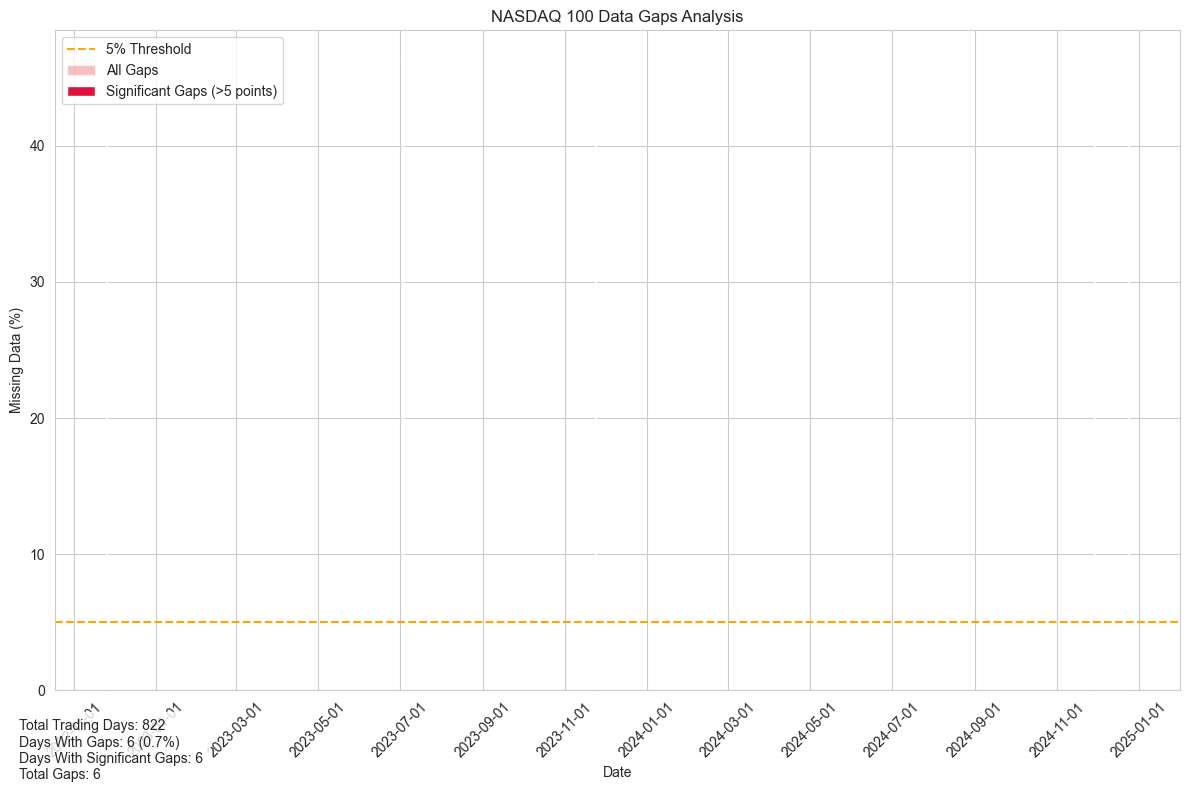

Days with more than 10 missing points: 6
2022-11-25: Missing 1079 of 2338 points
2023-07-03: Missing 1079 of 2338 points
2023-11-24: Missing 1079 of 2338 points
2024-07-03: Missing 1079 of 2338 points
2024-11-29: Missing 1079 of 2338 points
2024-12-24: Missing 1079 of 2338 points


In [1]:
from Helpers import checkDataFile, visualize_data_gaps
import matplotlib.pyplot as plt

symbol = 'NDX'
interval = '10secs'
start_date = '20220214'
end_date = '20250604'
price_source= 'TRADES'

# 1. Load the existing dataframe
save_path = f"../marketData/{symbol}_{interval}_{start_date}_to_{end_date}_{price_source}.csv"

# Analyze data gaps
report = checkDataFile(
    file_path=save_path, 
    interval=interval
)

# Print summary
print(f"Analyzed {report['total_trading_days']} trading days")
print(f"Found {report['days_with_gaps']} days with gaps ({report['analysis_summary']['gap_percentage']:.2f}%)")
print(f"Total gaps detected: {report['total_gaps']}")

# Visualize the gaps
fig = visualize_data_gaps(report)
plt.show()

# To examine specific days with large gaps
problem_days = {date: data for date, data in report["gaps_by_date"].items() 
                if data["missing_points"] > 10}
print(f"Days with more than 10 missing points: {len(problem_days)}")
for date, data in sorted(problem_days.items()):
    print(f"{date}: Missing {data['missing_points']} of {data['expected_points']} points")